In [1]:
# Importing relevant libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
from datetime import datetime

import warnings
warnings.filterwarnings("ignore")

## Objective for this noteboook: Analyze prompt repetitions and how it is associated with success rate 


In [2]:

# "all_CAR.csv" is assumed to be a dataset containing all CAR data, processed through Krish's "CAR_data_import_code.ipynb" code 
 
df_main = pd.read_csv("all_CAR.csv", usecols=lambda c: c != "Unnamed: 0")

### Date Filtering/Time Delta

In [3]:
# converting times into the right format
df_main["Activity Start Timestamp"] = df_main["Activity Start Timestamp"].apply(
    lambda x: datetime.strptime(x, "%Y-%m-%d %H:%M:%S")  
)

# Creating a new column 'hour' as it will be useful to visualize peak calling hours
df_main["hour"] = df_main["Activity Start Timestamp"].dt.hour


# --- 1) FILTER ROWS ---------------------------------------------------------

# Define the three conditions

# Rows that represent a particular menu
cond1 = (
    df_main['EP Name'].notna() &
    df_main['Flow Name'].isna() &
    df_main['Activity Name'].isna()
)

# Rows that represent the beginning / end of a call journey
cond2 = (
    df_main['EP Name'].notna() &
    df_main['Activity Name'].notna() &
    df_main['Flow Name'].isna()
)

# rows that represent presence within a queue
cond3 = df_main['Queue Name'].notna()

# Keep rows that satisfy ANY of the three conditions
df_filt = df_main[cond1 | cond2 | cond3].copy()

# --- 2) TIME DELTA (seconds since previous row within each Contact Session ID) -- 

# Ensure timestamp is datetime (safe if it's already datetime64[ns])
df_filt['Activity Start Timestamp'] = pd.to_datetime(df_filt['Activity Start Timestamp'], errors='coerce')

# Sort so "previous row" is truly the prior event in time for that session
# df_filt = df_filt.sort_values(['Contact Session ID', 'Activity Start Timestamp'])

# Compute per-session time difference (first row per session will be NaN)
df_filt['seconds_since_prev'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .diff()
           .dt.total_seconds()
)

# b) seconds until next row (last row per session -> NaN)
df_filt['seconds_until_next'] = (
    df_filt.groupby('Contact Session ID')['Activity Start Timestamp']
           .shift(-1)
           .sub(df_filt['Activity Start Timestamp'])
           .dt.total_seconds()
)

# df_filt now has the filtered rows plus the new 'seconds_since_prev' columnv

# Keep only rows where both times are >= 0. Not sure why there are such observations. 
df_filt = df_filt[(df_filt["seconds_since_prev"] >= 0) & (df_filt["seconds_until_next"] >= 0)]  



### Creating Some new Columns

In [5]:
df_new = df_filt.copy()
df_new = df_new.sort_values(["Contact Session ID", "Activity Start Timestamp"])

# 1. Identify valid rows and consecutive runs
mask_valid = df_new["Activity Name"].notna()
new_run = ((df_new["Contact Session ID"] != df_new["Contact Session ID"].shift()) | (df_new["Activity Name"] != df_new["Activity Name"].shift()) | (~mask_valid))   
df_new["run_id"] = new_run.cumsum()

run_stats = (
    df_new.groupby("run_id", sort=False)
    .agg(
        run_size=("Activity Name", "size"),
        run_total_seconds=("seconds_until_next", "sum"),
        contact_id=("Contact Session ID", "first")
    )
)
df_new = df_new.merge(run_stats[["run_size", "run_total_seconds"]], on="run_id", how="left")
df_new["num_consecutive_visits"] = df_new["run_size"].where(mask_valid, 0).clip(lower=0)

# 3. Queue info

# contains 'queue' in Activity Name (case-insensitive)
df_new['queue_hit'] = df_new['Activity Name'].astype(str).str.contains('queue', case=False, na=False)
# Queue Name is not null
df_new['queue_present'] = df_new['Queue Name'].notna()
# Call_successful = 1 if either condition occurs anywhere in the session
df_new['call_successful'] = (
    (df_new['queue_hit']| df_new['queue_present'])
      .groupby(df_new['Contact Session ID'])
      .transform('max')
      .astype(int)
)

df_new['queue_reached'] = (df_new['queue_hit'] | df_new['queue_present']).astype(int)

# 4. Pre-queue mask per call: filters only rows that are pre queue 
df_new["pre_queue_mask"] = (
    ~df_new.groupby("Contact Session ID")["queue_reached"]
    .transform("cummax")
).astype(bool)


# 5. Compute prompt repeats (only pre-queue)
# Filter pre-queue rows first for speed
df_pre_queue = df_new[df_new["pre_queue_mask"]].copy()

# create a dataframe where we calculate number of visits for each prompt for each call 
prompt_counts = (df_pre_queue.groupby(["Contact Session ID", "Activity Name"]).size().rename("prompt_total_visits_in_call").reset_index())

# number of repeats is just total visits - 1 
prompt_counts["prompt_num_repeats_in_call"] = (prompt_counts["prompt_total_visits_in_call"] - 1).clip(lower=0)

#  compute total repeats per call directly
total_repeats_per_call = (prompt_counts.groupby("Contact Session ID")["prompt_num_repeats_in_call"].sum())

# merge back 
df_new = df_new.merge(prompt_counts, on=["Contact Session ID", "Activity Name"], how="left")
# fill with na since we do not consider the repetitions that are activity names after one has entered a queue. 
df_new["prompt_total_visits_in_call"] = df_new["prompt_total_visits_in_call"].fillna(0)
df_new["prompt_num_repeats_in_call"] = df_new["prompt_num_repeats_in_call"].fillna(0)
df_new["prompt_repeated_in_call"] = (df_new["prompt_num_repeats_in_call"] > 0).astype(int)

df_new = df_new.merge(total_repeats_per_call.rename("total_repeats_per_call"), on="Contact Session ID",how="left")
df_new["total_repeats_per_call"] = df_new["total_repeats_per_call"].fillna(0).astype(int)


# --- Total Movements and Total Unique Nodes ---

# Sort just in case
df_new = df_new.sort_values(["Contact Session ID", "Activity Start Timestamp"])

# Define a "movement" as a change in Activity Name within a call
df_new["movement_flag"] = (
    (df_new["Activity Name"] != df_new["Activity Name"].shift()) &
    (df_new["Contact Session ID"] == df_new["Contact Session ID"].shift())
).astype(int)

# Count total movements per call (each change in node)
total_movements = (df_new[df_new["pre_queue_mask"]].groupby("Contact Session ID")["movement_flag"].sum().rename("total_movements"))

# Count total unique nodes per call 
total_unique_nodes = (df_new[df_new['pre_queue_mask']].groupby("Contact Session ID")["Activity Name"].nunique().rename("total_unique_nodes"))

# Merge both into df_new
df_new = df_new.merge(total_movements, on="Contact Session ID", how="left")
df_new = df_new.merge(total_unique_nodes, on="Contact Session ID", how="left")
df_new["total_movements"] = df_new["total_movements"].astype(int)
df_new["total_unique_nodes"] = df_new["total_unique_nodes"].astype(int)


# Create a variable that traces the path of a call 

# pre queue path, ignoring missing values
pre_queue_path_list = (
    df_new[df_new["pre_queue_mask"]]
    .groupby("Contact Session ID")["Activity Name"]
    .apply(lambda x: [str(i) for i in x if pd.notna(i)])  # ignore NaN, return a list of strings in order to represent the path taken 
)
# Map back to df_new
df_new["pre_queue_path_list"] = df_new["Contact Session ID"].map(pre_queue_path_list)

# 2. Path as string
df_new["pre_queue_path_str"] = df_new["Contact Session ID"].map(pre_queue_path_list.apply(lambda x: " -> ".join(x)))


# --- Append specific queue outcome to pre-queue path ---

def get_queue_outcome_with_node(group):
    # Check queue hits by Activity Name first
    queue_activity_rows = group.loc[group["queue_hit"]]
    if not queue_activity_rows.empty:
        # Get the first Activity Name where queue_hit = True
        node = queue_activity_rows["Activity Name"].iloc[0]
        return f"queue_hit: {node}"

    # Then check queue hits by Queue Name
    queue_name_rows = group.loc[group["queue_present"]]
    if not queue_name_rows.empty:
        # Get the first Queue Name where queue_present = True
        node = queue_name_rows["Queue Name"].iloc[0]
        return f"queue_present: {node}"

    # If neither found
    return "didnt_reach_queue"

# Apply per Contact Session
queue_outcomes_detailed = df_new.groupby("Contact Session ID").apply(get_queue_outcome_with_node)

# Append outcome node info to path list
final_path_list = (
    pre_queue_path_list
    .combine(queue_outcomes_detailed, lambda path, outcome: path + [outcome] if isinstance(path, list) else [outcome])
)

# Map back to df_new
df_new["full_path_list"] = df_new["Contact Session ID"].map(final_path_list)
df_new["full_path_str"] = df_new["Contact Session ID"].map(final_path_list.apply(lambda x: " -> ".join(x)))



# SAVE DATASET 
df_new.to_csv("Presentation3_df.csv", index=False)

## Analysis

In [6]:
# read the dataset 

df = pd.read_csv('Presentation3_df.csv')

#### Visualize distribution of calls by number of repeats

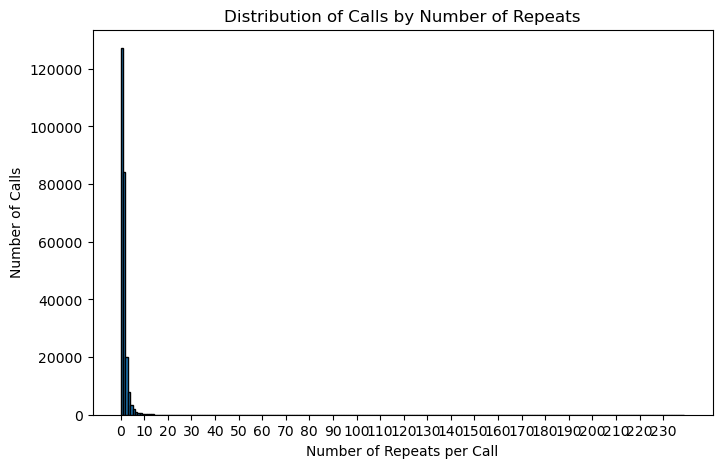

In [4]:
# visualize distribution of calls by number of repeats, to see what is the best range. 

calls = df[['Contact Session ID', 'total_repeats_per_call']].drop_duplicates(subset=['Contact Session ID'])

# Plot histogram
plt.figure(figsize=(8,5))
max_repeats = int(np.ceil(calls['total_repeats_per_call'].max()))

plt.hist(
    calls['total_repeats_per_call'],
    bins=range(0, max_repeats + 2),  # +2 ensures the last integer has its own bin
    edgecolor='black'
)

plt.xlabel('Number of Repeats per Call')
plt.ylabel('Number of Calls')
plt.xticks(range(0, max_repeats + 1, 10))
plt.title('Distribution of Calls by Number of Repeats')
plt.show()

The above plot shows us that majority of calls have less than 15 total number of repeats. We will zoom into specifically that subset of the data

In [6]:
# Identify calls where total repeats > 50
normal_rep_calls = df[df["total_repeats_per_call"] <= 15]["Contact Session ID"].unique()

# Subset all rows for these calls
df_normal_rep = df[df["Contact Session ID"].isin(normal_rep_calls)].copy()


#### Plot for call success rate by total number of repeats 

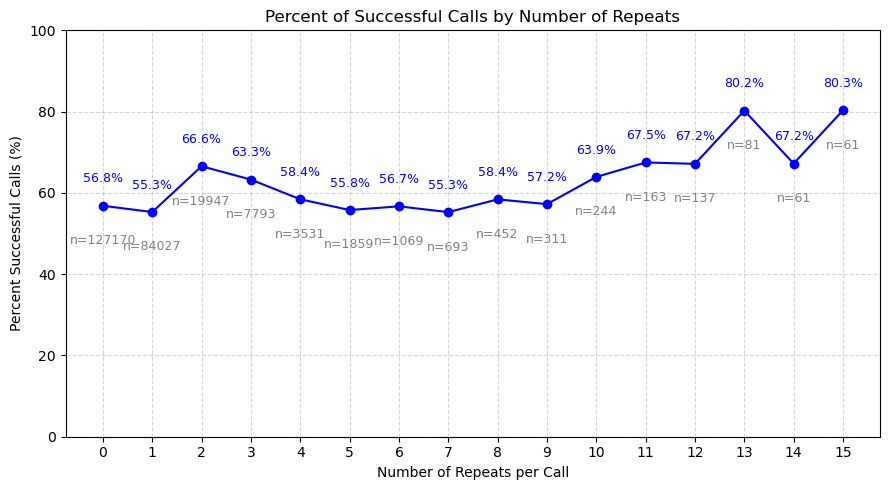

In [7]:
calls = df_normal_rep.groupby("Contact Session ID").agg({
    "total_repeats_per_call": "first",
    "call_successful": "first"
}).reset_index()

# Compute success rate (%) and count per repeat level
success_by_repeats = calls.groupby("total_repeats_per_call")["call_successful"].mean() * 100
counts_by_repeats = calls["total_repeats_per_call"].value_counts().sort_index()

plt.figure(figsize=(9,5))
plt.plot(
    success_by_repeats.index,
    success_by_repeats.values,
    marker='o', color='blue'
)
plt.xlabel("Number of Repeats per Call")
plt.ylabel("Percent Successful Calls (%)")
plt.title("Percent of Successful Calls by Number of Repeats")
plt.xticks(range(0, 16))
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate each point with two separate labels
for x, y in zip(success_by_repeats.index, success_by_repeats.values):
    count = counts_by_repeats.get(x, 0)
    # success % above
    plt.text(x, y + 5, f"{y:.1f}%", ha='center', va='bottom', fontsize=9, color='blue')
    # count below
    plt.text(x, y - 7, f"n={count}", ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()


#### Legal Menu Repetitions and Success rate

In [8]:
df_normal_rep.columns

Index(['Contact Session ID', 'EP Name', 'Flow Name', 'Activity Name',
       'Activity Start Timestamp', 'Queue Name', 'Agent Name',
       'Termination Reason', 'hour', 'seconds_since_prev',
       'seconds_until_next', 'run_id', 'run_size', 'run_total_seconds',
       'num_consecutive_visits', 'queue_hit', 'queue_present',
       'call_successful', 'queue_reached', 'pre_queue_mask',
       'prompt_total_visits_in_call', 'prompt_num_repeats_in_call',
       'prompt_repeated_in_call', 'total_repeats_per_call', 'movement_flag',
       'total_movements', 'total_unique_nodes', 'pre_queue_path_list',
       'pre_queue_path_str'],
      dtype='object')

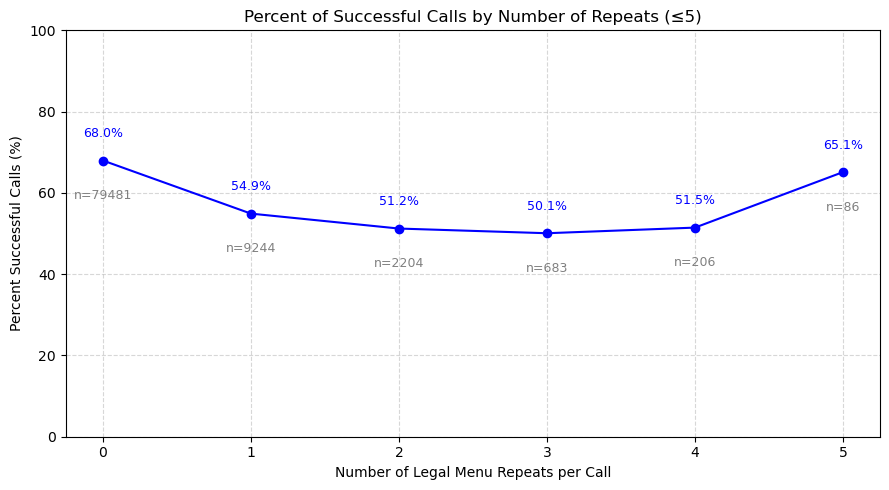

In [15]:
# Filter to repeats <= 5
calls = df_normal_rep[df_normal_rep['Activity Name']=='LegalMenu2'].groupby("Contact Session ID").agg({
    "prompt_num_repeats_in_call": "first",
    "call_successful": "first"
}).reset_index()

calls = calls[calls["prompt_num_repeats_in_call"] <= 5]

# Compute success rate (%) and count per repeat level
success_by_repeats = calls.groupby("prompt_num_repeats_in_call")["call_successful"].mean() * 100
counts_by_repeats = calls["prompt_num_repeats_in_call"].value_counts().sort_index()

plt.figure(figsize=(9,5))
plt.plot(
    success_by_repeats.index,
    success_by_repeats.values,
    marker='o', color='blue'
)
plt.xlabel("Number of Legal Menu Repeats per Call")
plt.ylabel("Percent Successful Calls (%)")
plt.title("Percent of Successful Calls by Number of Repeats (≤5)")
plt.xticks(range(0, 6))
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate each point with two separate labels
for x, y in zip(success_by_repeats.index, success_by_repeats.values):
    count = counts_by_repeats.get(x, 0)
    # success % above
    plt.text(x, y + 5, f"{y:.1f}%", ha='center', va='bottom', fontsize=9, color='blue')
    # count below
    plt.text(x, y - 7, f"n={count}", ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()



#### Main Menu repetitions and success rate

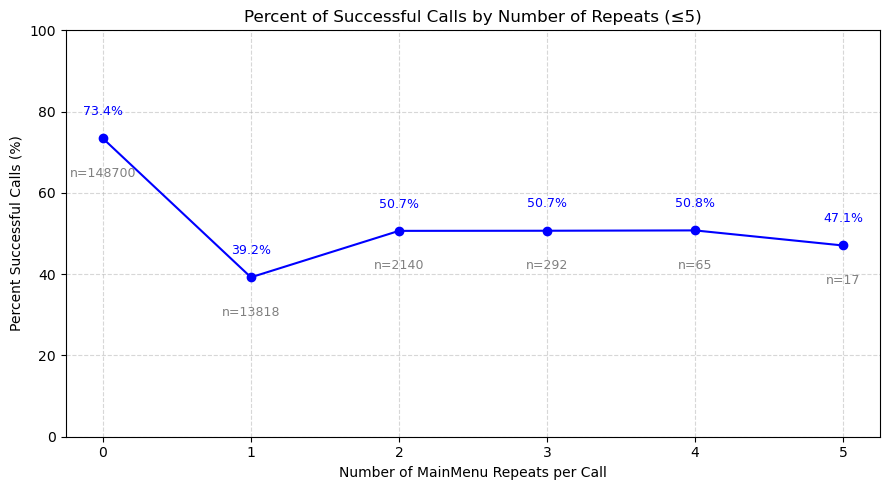

In [19]:
# Filter to repeats <= 5
calls = df_normal_rep[df_normal_rep['Activity Name']=='MainMenu'].groupby("Contact Session ID").agg({
    "prompt_num_repeats_in_call": "first",
    "call_successful": "first"
}).reset_index()

calls = calls[calls["prompt_num_repeats_in_call"] <= 5]

# Compute success rate (%) and count per repeat level
success_by_repeats = calls.groupby("prompt_num_repeats_in_call")["call_successful"].mean() * 100
counts_by_repeats = calls["prompt_num_repeats_in_call"].value_counts().sort_index()

plt.figure(figsize=(9,5))
plt.plot(
    success_by_repeats.index,
    success_by_repeats.values,
    marker='o', color='blue'
)
plt.xlabel("Number of MainMenu Repeats per Call")
plt.ylabel("Percent Successful Calls (%)")
plt.title("Percent of Successful Calls by Number of Repeats (≤5)")
plt.xticks(range(0, 6))
plt.ylim(0, 100)
plt.grid(True, linestyle='--', alpha=0.5)

# Annotate each point with two separate labels
for x, y in zip(success_by_repeats.index, success_by_repeats.values):
    count = counts_by_repeats.get(x, 0)
    # success % above
    plt.text(x, y + 5, f"{y:.1f}%", ha='center', va='bottom', fontsize=9, color='blue')
    # count below
    plt.text(x, y - 7, f"n={count}", ha='center', va='top', fontsize=9, color='gray')

plt.tight_layout()
plt.show()
